# Graphic 3: Global Mean Estimates based on Land and Ocean Data
Replication of NASA GISS's chart of the global annual mean surface temperature anomaly (relative to 1951-1980), with a Lowess-smoothed trend, using GISTEMP v4 data.

## 1. Setup
Import the libraries and define paths relative to the repo root, since this notebook runs from `scripts/`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


ROOT = Path.cwd().parent
DATA = ROOT /"data"
OUT = ROOT /"outputs"
OUT.mkdir(exist_ok=True)

## 2. Load the data
The file starts with a quoted two-line title (which pandas reads as one row) and a header with a column named `Lowess(5)`, so we skip 2 rows and name the columns ourselves.

In [2]:
columns = ["year", "annual_mean", "lowess"]
df = pd.read_csv(DATA/"graphic3_global_mean.csv", skiprows= 2, names= columns)

df.head()

,year,annual_mean,lowess
0,1880,-0.18,-0.10
1,1881,-0.09,-0.14
2,1882,-0.12,-0.18
3,1883,-0.18,-0.21
4,1884,-0.29,-0.25


## 3. Inspect and clean
Convert every column to numbers, drop rows without a year, and check the shape, missing values and summary statistics.

In [3]:
df = df.apply(pd.to_numeric, errors="coerce")  
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

print(df.shape)
print(df.isna().sum())
df.describe()

(146, 3)
year           0
annual_mean    0
lowess         0
dtype: int64


,year,annual_mean,lowess
count,146.000000,146.000000,146.000000
mean,1952.500000,0.081233,0.081986
std,42.290661,0.402542,0.394400
min,1880.000000,-0.490000,-0.420000
25%,1916.250000,-0.200000,-0.220000
50%,1952.500000,-0.030000,-0.035000
75%,1988.750000,0.317500,0.325000
max,2025.000000,1.290000,1.230000


## 4. Create the plot
A function that draws the annual mean (black squares) and its Lowess smoothing (red), styled to match NASA's chart, and returns the figure and axes.

In [4]:
def plot_global_mean(df):
    """Recreate NASA's global mean land-ocean temperature anomaly chart."""
    fig, ax = plt.subplots(figsize=(11, 6.5))

    ax.plot(df["year"], df["annual_mean"], color="black", marker="s",
            markersize=5, linewidth=1, label="Annual Mean")
    ax.plot(df["year"], df["lowess"], color="#E8301E", linewidth=2.5,
            label="Lowess Smoothing")

    ax.set_title("Global Mean Estimates based on Land and Ocean Data", fontsize=16)
    ax.set_ylabel("Temperature Anomaly w.r.t. 1951-80 (°C)", fontsize=14)
    ax.set_xticks(range(1880, 2021, 20))
    ax.set_xlim(1873, 2032)
    ax.set_yticks(np.arange(-0.6, 1.41, 0.2))  # a tick every 0.2 °C
    ax.yaxis.set_major_formatter("{x:.1f}") # labels like -0.6, -0.4, ..., 1.4
    ax.set_ylim(-0.7, 1.45)
    ax.tick_params(labelsize=13)
    ax.legend(loc="upper left", frameon=True, fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.99, 0.05, "NASA/GISS/GISTEMP v4", transform=ax.transAxes,
            ha="right", fontsize=14, color="#333333")
    return fig, ax

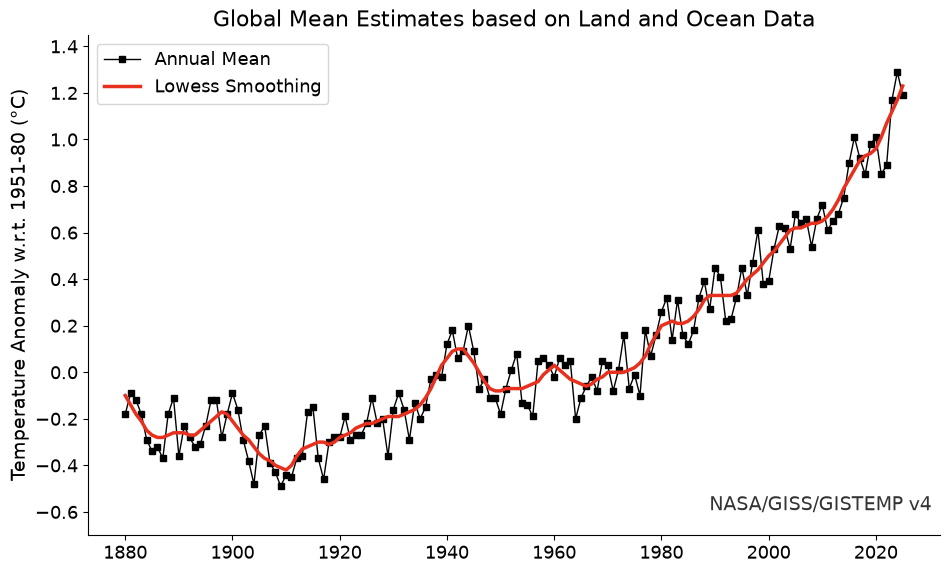

In [5]:
fig, ax = plot_global_mean(df)

plt.show()

## 5. Save the figure
Save the figure to `outputs/` as both PNG and PDF.

In [6]:
fig.savefig(OUT / "graphic3_global_mean.png", dpi=300, bbox_inches="tight")

fig.savefig(OUT / "graphic3_global_mean.pdf", bbox_inches="tight", metadata={"CreationDate": None})

## 6. Notes
Global temperatures stayed within about 0.3 °C of the 1951-1980 average until the late 1970s, then rose steadily; the smoothed anomaly is about +1.2 °C by 2025. Differences from NASA's chart: the gray "LSAT+SST Uncertainty" band is omitted because the downloaded CSV contains only the annual mean and Lowess columns, and colors and fonts are approximated by eye.